<a href="https://colab.research.google.com/github/watch-duty/radio-transcription/blob/GOO-37-model-eval-improvements/evaluate_transcriptions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Colab to compute metrics from a JSON manifest with transcriptions from various models.

The google drive version of this colab (for iterating and editing) [is here](https://colab.research.google.com/drive/1HJs9lUMsg5dyK4uwuLmzxzbtKEE9tkbi?authuser=1#scrollTo=72af-Ue2_BwC). Once you have a unit of edit completed, you can check-in the drive version into [this github directory](https://github.com/watch-duty/radio-transcription/tree/main/model/colabs).

In [ ]:
!pip install evaluate torch
!pip install bert_score
!pip install nemo_toolkit['asr']
!pip install nemo_text_processing

  Using cached nemo_text_processing-1.1.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached cdifflib-1.2.9.tar.gz (12 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 MB 6.8 MB/s eta 0:00:00
  Created wheel for cdifflib: filename=cdifflib-1.2.9-cp312-cp312-linux_x86_64.whl size=29762 sha256=6d9f344ef13e2a0b0afc0af2030993d08ab1e876975c0437f08c1f753a03825a
  Stored in directory: /root/.cache/pip/wheels/4b/26/dc/0c60f17cb2fee90ffc80231b11cd034572cd05c64711a74534
Successfully built cdifflib


In [ ]:
from google.colab import files

print("Please select the file 'playground_parakeet_and_canary_flash.json' from your local machine.")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

# After uploading, the file will be in the current working directory, e.g., '/content/playground_parakeet_and_canary_flash.json'
# You might need to update the `inference_results` variable accordingly.
# For example, if the uploaded file name is exactly 'playground_parakeet_and_canary_flash.json':
# inference_results = '/content/playground_parakeet_and_canary_flash.json'

Please select the file 'playground_parakeet_and_canary_flash.json' from your local machine.


Saving playground_parakeet_and_canary_flash.json to playground_parakeet_and_canary_flash.json
User uploaded file "playground_parakeet_and_canary_flash.json" with length 16747 bytes


In [ ]:
#@title Imports
import json
import os
import evaluate # Import the evaluate library
from nemo.collections.asr.parts.utils import transcribe_utils
from nemo.collections.asr.metrics.wer import word_error_rate
# Removed problematic ITN import: import nemo.collections.asr.parts.utils.InverseTextNormalizer as InverseNormalizer

inference_results = "/content/playground_parakeet_and_canary_flash.json"  #@param
postfixes_to_eval = ['parakeet-tdt-06b-v2', 'canary-1b-flash']  #@param
eval_output = "/tmp/playground_parakeet_and_canary_flash_eval.json"

# Load the BERTScore metric
bertscore = evaluate.load("bertscore")

# Removed problematic ITN initialization: itn_processor = InverseNormalizer(lang='en')

[NeMo W 2026-02-23 17:26:16 nemo_logging:405] Megatron num_microbatches_calculator not found, using Apex version.
[NeMo W 2026-02-23 17:26:17 nemo_logging:405] /usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
      m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
    
[NeMo W 2026-02-23 17:26:17 nemo_logging:405] /usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
      m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
    
[NeMo W 2026-02-23 17:26:17 nemo_logging:405] /usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
      elif re.match('(flt)p?( \(default\))?$', token):
    
[NeMo W 2026-02-23 17:26:17 nemo_logging:405] /usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
      elif re.match('(dbl)p?( \(default\))?$', token):
    


In [ ]:

#@title Imports
import json
import os
import evaluate # Import the evaluate library
from nemo.collections.asr.parts.utils import transcribe_utils
from nemo.collections.asr.metrics.wer import word_error_rate
from nemo_text_processing.inverse_text_normalization.inverse_normalize import InverseNormalizer
import pandas as pd

inference_results = "/content/playground_parakeet_and_canary_flash.json"  #@param
postfixes_to_eval = ['parakeet-tdt-06b-v2', 'canary-1b-flash']  #@param
eval_output = "/tmp/playground_parakeet_and_canary_flash_eval.json"

itn_processor = InverseNormalizer(lang='en')

# Load the BERTScore metric
bertscore = evaluate.load("bertscore")

 NeMo-text-processing :: INFO     :: Creating ClassifyFst grammars.
INFO:NeMo-text-processing:Creating ClassifyFst grammars.


In [ ]:
import json
import os
import evaluate # Import the evaluate library
from nemo.collections.asr.parts.utils import transcribe_utils
from nemo.collections.asr.metrics.wer import word_error_rate

def _process_single_row(
    data_row,
    gt_text_field,
    prediction_field_prefix,
    itn_processor,
    pc_processor,
    postfixes_to_eval,
    bertscore
):
  """Processes a single data row to calculate WER and BERTScore."""
  audio_filepath = data_row["audio_filepath"]
  ground_truth_text_raw = data_row.get(gt_text_field, "")

  # Remove <unknown> token from ground_truth_text_raw
  ground_truth_text_raw = ground_truth_text_raw.replace("<unknown>", "").strip()

  if not ground_truth_text_raw:
    print(f"Skipping example: {audio_filepath}, ground truth is empty or only <unknown> after processing")
    return None, None, None, True # Indicate skipped row

  # Apply ITN to ground truth text, this converts numbers to string representation.
  ground_truth_text_itn = [itn_processor.inverse_normalize(text=ground_truth_text_raw, verbose=False)]

  # Check if all models have a prediction for this row
  for postfix in postfixes_to_eval:
    pred_text_field = prediction_field_prefix + postfix
    predicted_text_value = data_row.get(pred_text_field)
    if predicted_text_value is None or predicted_text_value == "":
      print(f"Skipping example: {audio_filepath}, missing or empty prediction for model: {postfix}")
      return None, None, None, True # Indicate skipped row

  # Process ITN'd ground truth text for WER
  ground_truth_text_processed = pc_processor.do_lowercase(ground_truth_text_itn)
  ground_truth_text_processed = pc_processor.rm_punctuation(ground_truth_text_processed)

  output_row = data_row.copy()
  # Add processed ground truth to output_row
  output_row['ground_truth_processed'] = ground_truth_text_processed[0]

  predictions_processed_by_postfix = {}
  for postfix in postfixes_to_eval:
    pred_text_field = prediction_field_prefix + postfix
    predicted_text_raw = data_row.get(pred_text_field)

    # Apply ITN to predicted text
    predicted_text_itn = [itn_processor.inverse_normalize(text=predicted_text_raw, verbose=False)]

    # Process ITN'd predicted text for WER
    predicted_text_processed = pc_processor.do_lowercase(predicted_text_itn)
    predicted_text_processed = pc_processor.rm_punctuation(predicted_text_processed)
    predictions_processed_by_postfix[postfix] = predicted_text_processed

    sample_wer = word_error_rate(hypotheses=predicted_text_processed, references=ground_truth_text_processed, use_cer=False)
    sample_wer = round(100 * sample_wer, 2)
    output_row["wer_" + postfix] = sample_wer

    # Calculate BERTScore using ITN'd texts
    bertscore_results = bertscore.compute(predictions=predicted_text_itn, references=ground_truth_text_itn, lang="en")
    output_row[f"bertscore_f1_{postfix}"] = round(bertscore_results['f1'][0], 4)
    output_row[f"bertscore_precision_{postfix}"] = round(bertscore_results['precision'][0], 4)
    output_row[f"bertscore_recall_{postfix}"] = round(bertscore_results['recall'][0], 4)

    # Add processed predicted text to output_row
    output_row[f'pred_text_processed_{postfix}'] = predicted_text_processed[0]

  return output_row, ground_truth_text_processed, predictions_processed_by_postfix, False

def _calculate_and_print_aggregate_metrics(all_ground_truths, all_predictions_by_postfix, postfixes_to_evaluate, output_json):
  """Calculates and prints aggregate WER and BERTScore metrics."""
  print("\n--- Aggregate Metrics ---")
  for postfix in postfixes_to_evaluate:
    dataset_wer = word_error_rate(hypotheses=all_predictions_by_postfix[postfix], references=all_ground_truths, use_cer=False)
    dataset_wer = round(100 * dataset_wer, 2)
    print(f"Dataset WER for {postfix}: {dataset_wer:.1f}")

    # Aggregate BERTScore (mean of all F1 scores)
    all_f1_scores = []
    with open(output_json, 'r', encoding='utf-8') as temp_f:
        for line in temp_f:
            row = json.loads(line)
            if f"bertscore_f1_{postfix}" in row:
                all_f1_scores.append(row[f"bertscore_f1_{postfix}"])
    if all_f1_scores:
        avg_f1 = sum(all_f1_scores) / len(all_f1_scores)
        print(f"Dataset BERTScore F1 for {postfix}: {avg_f1:.4f}")

def run_evaluation(input_json, output_json, postfixes_to_evaluate):

  gt_text_field = "text"
  prediction_field_prefix = "pred_text_"
  pc_processor = transcribe_utils.PunctuationCapitalization(".,?")

  total_rows = 0
  skipped_rows = 0
  evaluated_rows = 0

  all_ground_truths = []
  all_predictions_by_postfix = {postfix: [] for postfix in postfixes_to_evaluate}

  with open(input_json, 'r', encoding='utf-8') as f_in, \
       open(output_json, 'w', encoding='utf-8') as f_out:

    for line in f_in:
      total_rows += 1
      data_row = json.loads(line)

      output_row, gt_processed, preds_processed_by_postfix, was_skipped = \
          _process_single_row(data_row, gt_text_field, prediction_field_prefix,
                              itn_processor, pc_processor, postfixes_to_evaluate, bertscore)

      if was_skipped:
        skipped_rows += 1
        continue

      evaluated_rows += 1
      all_ground_truths.extend(gt_processed)
      for postfix, preds in preds_processed_by_postfix.items():
          all_predictions_by_postfix[postfix].extend(preds)

      f_out.write(json.dumps(output_row) + '\n')

  _calculate_and_print_aggregate_metrics(all_ground_truths, all_predictions_by_postfix, postfixes_to_evaluate, output_json)

  print(f"\nSuccessfully evaluated {input_json}\nWrote per sample evaluation to: {output_json}")
  print(f"\n--- Row Statistics ---")
  print(f"Total rows in manifest: {total_rows}")
  print(f"Skipped rows (missing ground truth or prediction): {skipped_rows}")
  print(f"Evaluated rows: {evaluated_rows}")


In [ ]:
run_evaluation(inference_results, eval_output, postfixes_to_eval)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Skipping example: /usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3, missing or empty prediction for model: canary-1b-flash
Skipping example: /usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3, missing or empty prediction for model: parakeet-tdt-06b-v2
Skipping example: /usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3, missing or empty prediction for model: canary-1b-flash
Skipping example: /usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/cc8dfbdd-202601141225-371759-141.mp3, missing or empty prediction for model: canary-1b-flash
Skipping example: /usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/adc69b77-AEU-DISP_2026-01-03_12-18-41.mp3, missing or 

In [ ]:
#@title  Visualize results

# Define a styling function for BERTScore F1 values
def highlight_bertscore(s):
    # s is a Series representing a row
    # Return a Series of style strings for each cell in the row
    styles = [''] * len(s)
    for i, (col_name, value) in enumerate(s.items()):
        if col_name.startswith('bertscore_f1_'):
            if pd.notna(value):
                if value >= 0.9:
                    styles[i] = 'background-color: #d4edda' # Light green
                elif value >= 0.7:
                    styles[i] = 'background-color: #fff3cd' # Light yellow
                else: # value < 0.7
                    styles[i] = 'background-color: #f8d7da' # Light red
    return styles

# Define a styling function for WER values
def highlight_wer(s):
    # s is a Series representing a row
    # Return a Series of style strings for each cell in the row
    styles = [''] * len(s)
    for i, (col_name, value) in enumerate(s.items()):
        if col_name.startswith('wer_'):
            if pd.notna(value):
                if value < 5:  # Excellent
                    styles[i] = 'background-color: #d4edda' # Light green
                elif value < 30: # Moderate
                    styles[i] = 'background-color: #fff3cd' # Light yellow
                else: # Poor
                    styles[i] = 'background-color: #f8d7da' # Light red
    return styles

# Load the evaluation output JSON into a DataFrame
df_eval = pd.read_json(eval_output, lines=True)

# Prepare columns for display
display_columns = ['audio_filepath', 'text', 'ground_truth_processed']

# These lists are used for calculating overall metrics, not directly for display here
bertscore_f1_cols = []
wer_cols = []

# Populate all available WER and BERTScore F1 columns for overall calculations
for postfix in postfixes_to_eval:
    if f'wer_{postfix}' in df_eval.columns:
        wer_cols.append(f'wer_{postfix}')
    if f'bertscore_f1_{postfix}' in df_eval.columns:
        bertscore_f1_cols.append(f'bertscore_f1_{postfix}')

# Add all relevant columns (pred_text, WER, BERTScore F1, and processed pred_text) for each model to display_columns
for postfix in postfixes_to_eval:
    if f'pred_text_{postfix}' in df_eval.columns:
        display_columns.append(f'pred_text_{postfix}')
    if f'pred_text_processed_{postfix}' in df_eval.columns:
        display_columns.append(f'pred_text_processed_{postfix}')
    if f'wer_{postfix}' in df_eval.columns:
        display_columns.append(f'wer_{postfix}')
    if f'bertscore_f1_{postfix}' in df_eval.columns:
        display_columns.append(f'bertscore_f1_{postfix}')

# Calculate overall BERTScore F1 for sorting (mean across all models)
df_eval['overall_bertscore_f1'] = df_eval[bertscore_f1_cols].mean(axis=1)

# Display examples with low overall BERTScore F1
print("\n--- Examples with Low Overall BERTScore (F1) Across All Models ---")
display(df_eval.sort_values(by='overall_bertscore_f1', ascending=True)[display_columns + ['overall_bertscore_f1']].head(10).style.apply(highlight_bertscore, axis=1).apply(highlight_wer, axis=1))

# Display examples with high overall BERTScore F1
print("\n--- Examples with High Overall BERTScore (F1) Across All Models ---")
display(df_eval.sort_values(by='overall_bertscore_f1', ascending=False)[display_columns + ['overall_bertscore_f1']].head(10).style.apply(highlight_bertscore, axis=1).apply(highlight_wer, axis=1))

# Calculate overall WER for sorting (mean across all models)
df_eval['overall_wer'] = df_eval[wer_cols].mean(axis=1)

# Display examples with high overall WER Across All Models
print("\n--- Examples with High Overall WER Across All Models ---")
display(df_eval.sort_values(by='overall_wer', ascending=False)[display_columns + ['overall_wer']].head(10).style.apply(highlight_bertscore, axis=1).apply(highlight_wer, axis=1))

# Display examples with low overall WER Across All Models
print("\n--- Examples with Low Overall WER Across All Models ---")
display(df_eval.sort_values(by='overall_wer', ascending=True)[display_columns + ['overall_wer']].head(10).style.apply(highlight_bertscore, axis=1).apply(highlight_wer, axis=1))


--- Examples with Low Overall BERTScore (F1) Across All Models ---


,audio_filepath,text,ground_truth_processed,pred_text_parakeet-tdt-06b-v2,pred_text_processed_parakeet-tdt-06b-v2,wer_parakeet-tdt-06b-v2,bertscore_f1_parakeet-tdt-06b-v2,pred_text_canary-1b-flash,pred_text_processed_canary-1b-flash,wer_canary-1b-flash,bertscore_f1_canary-1b-flash,overall_bertscore_f1
23,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/9f66242e-202601140834-936159-909.mp3,107 your message received,107 your message received,What else earlier Massachusetts?,what else earlier massachusetts,100.000000,0.801600,"One or the other, your master perceived it.",one or the other your master perceived it,175.000000,0.799000,0.800300
9,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"coyote IC, camino, _____ go ahead",coyote ic camino _____ go ahead,"Hi ODIC, we know three IT tones, go ahead.",hi odic we know three it tones go ahead,116.670000,0.830200,"Hi, I'm Dean, I think we know three or four times please go ahead.",hi i'm dean i think we know three or four times please go ahead,200.000000,0.798200,0.814200
11,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"camino, coyote IC, resource request",camino coyote ic resource request,Can you get a Kaio DC resource request?,can you get a kaio dc resource request,120.000000,0.835000,Can you give me a high O. D. C. resource request?,can you give me a high o d c resource request,180.000000,0.831100,0.833050
12,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"coyote IC, camino, go ahead",coyote ic camino go ahead,"Hi early, very good.",hi early very good,100.000000,0.853500,"Hi, Odya, did you hear that?",hi odya did you hear that,120.000000,0.817400,0.835450
4,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,camino battalion 2710,camino battalion 2710,I've tuned it up at 927 ten.,i've tuned it up at 927 ten,233.330000,0.827300,Coming up at the time twenty seven ten.,coming up at the time 2710,166.670000,0.844200,0.835750
15,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"coyote IC, 1623",coyote ic 1623,Area C sixteen point.,area c 16 point,133.330000,0.850400,"Oh yeah, yeah, sixteen point four.",oh yeah yeah 16 4,166.670000,0.822600,0.836500
10,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"camino, coyote IC, stand by one.",camino coyote ic stand by one,Community ACSA Mm-12.,community acsa mm-12,100.000000,0.826500,"Come on, okay. I see you stand by one.",come on okay i see you stand by one,100.000000,0.851000,0.838750
17,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/06936ce3-ca_vacaville2F202506022FSolano_Co_Disp_20250602_16.mp3,vista grande and capitola for a vegetation fire,vista grande and capitola for a vegetation fire,Vista grande in Capitola for vegetation fries.,vista grande in capitola for vegetation fries,37.500000,0.841200,Vista Grande and Capitola for vegetation fries.,vista grande and capitola for vegetation fries,25.000000,0.845100,0.843150
3,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,battalion 2710 stand by,battalion 2710 stand by,The time when he doesn't turn tennis.,the time when he doesn't turn tennis,175.000000,0.836400,Battalion twenty seven pounds ten.,battalion 27 pounds ten,75.000000,0.855000,0.845700
8,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_2025


--- Examples with High Overall BERTScore (F1) Across All Models ---


,audio_filepath,text,ground_truth_processed,pred_text_parakeet-tdt-06b-v2,pred_text_processed_parakeet-tdt-06b-v2,wer_parakeet-tdt-06b-v2,bertscore_f1_parakeet-tdt-06b-v2,pred_text_canary-1b-flash,pred_text_processed_canary-1b-flash,wer_canary-1b-flash,bertscore_f1_canary-1b-flash,overall_bertscore_f1
21,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/cc8dfbdd-202601141225-371759-141.mp3,could i just have a status please on Lisa Mander?,could i just have a status please on lisa mander,Could I just have a status please on Lisa Mander?,could i just have a status please on lisa mander,0.000000,0.990300,Could I just have a status please on Lisa Manter?,could i just have a status please on lisa manter,10.000000,0.969000,0.979650
13,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"i'd like to request 15 agency engines, any configuration, 8 crews, 6 dozers, 6 water tenders",i'd like to request 15 agency engines any configuration 8 crews 6 dozers 6 water tenders,"I'd like to request 15 agency engines, any configuration, 8 crews, 6 dozers, 6 water tenders.",i'd like to request 15 agency engines any configuration 8 crews 6 dozers 6 water tenders,0.000000,0.995100,I'd like to request fifteen agency engines any configuration eight crews six dozers six water tenders.,i'd like to request 15 agency engines any configuration eight crews six dozers six water tenders,18.750000,0.960500,0.977800
7,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,show us in the area,show us in the area,Show us in the area.,show us in the area,0.000000,0.979400,Chill was in the area.,chill was in the area,40.000000,0.922400,0.950900
5,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"camino, battalion 2710 i'm gonna go ahead and assume the coyote IC. we're still making access to the fire based on air attack's directions. uh it's most likely going to be off the E line of uh farnam ridge.",camino battalion 2710 i'm gonna go ahead and assume the coyote ic we're still making access to the fire based on air attack's directions uh it's most likely going to be off the e line of uh farnam ridge,"Coming up with Italian 2710, I'm going to go ahead and assume the Coyote IC. We're still making access to the fire based on air attacks directions. It's most likely going to be off the E line of Farnham Ridge.",coming up with italian 2710 i'm going to go ahead and assume the coyote ic we're still making access to the fire based on air attacks directions it's most likely going to be off the e line of farnham ridge,25.640000,0.933100,"Coming up with time twenty seven ten, I'm going to go ahead and assume the coyote IC. We're still making access to the fire based on air tax directions. It's just most likely going to be off the E line of Farnham Ridge.",coming up with time 2710 i'm going to go ahead and assume the coyote ic we're still making access to the fire based on air tax directions it's just most likely going to be off the e line of farnham ridge,28.210000,0.923900,0.928500
0,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"testing on command 2 tone 2, with battalion 2710, 1508",testing on command 2 tone 2 with battalion 2710 1508,Testing on Command 2 Zone 2 for Battalion 2710 1508.,testing on command 2 zone 2 for battalion 2710 1508,20.000000,0.920600,"testing on command two, tone two for battalion twenty seven ten fifteen zero eight.",testing on command two tone two for battalion 2710 1508,30.000000,0.932800,0.926700
2,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,i'd like to r


--- Examples with High Overall WER Across All Models ---


,audio_filepath,text,ground_truth_processed,pred_text_parakeet-tdt-06b-v2,pred_text_processed_parakeet-tdt-06b-v2,wer_parakeet-tdt-06b-v2,bertscore_f1_parakeet-tdt-06b-v2,pred_text_canary-1b-flash,pred_text_processed_canary-1b-flash,wer_canary-1b-flash,bertscore_f1_canary-1b-flash,overall_wer
4,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,camino battalion 2710,camino battalion 2710,I've tuned it up at 927 ten.,i've tuned it up at 927 ten,233.330000,0.827300,Coming up at the time twenty seven ten.,coming up at the time 2710,166.670000,0.844200,200.000000
9,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"coyote IC, camino, _____ go ahead",coyote ic camino _____ go ahead,"Hi ODIC, we know three IT tones, go ahead.",hi odic we know three it tones go ahead,116.670000,0.830200,"Hi, I'm Dean, I think we know three or four times please go ahead.",hi i'm dean i think we know three or four times please go ahead,200.000000,0.798200,158.335000
11,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"camino, coyote IC, resource request",camino coyote ic resource request,Can you get a Kaio DC resource request?,can you get a kaio dc resource request,120.000000,0.835000,Can you give me a high O. D. C. resource request?,can you give me a high o d c resource request,180.000000,0.831100,150.000000
15,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"coyote IC, 1623",coyote ic 1623,Area C sixteen point.,area c 16 point,133.330000,0.850400,"Oh yeah, yeah, sixteen point four.",oh yeah yeah 16 4,166.670000,0.822600,150.000000
23,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/9f66242e-202601140834-936159-909.mp3,107 your message received,107 your message received,What else earlier Massachusetts?,what else earlier massachusetts,100.000000,0.801600,"One or the other, your master perceived it.",one or the other your master perceived it,175.000000,0.799000,137.500000
3,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,battalion 2710 stand by,battalion 2710 stand by,The time when he doesn't turn tennis.,the time when he doesn't turn tennis,175.000000,0.836400,Battalion twenty seven pounds ten.,battalion 27 pounds ten,75.000000,0.855000,125.000000
8,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"camino, coyote IC resource request. coyote IC, camino",camino coyote ic resource request coyote ic camino,Come in a coyote I see a resource request. Coyote I see here.,come in a coyote i see a resource request coyote i see here,112.500000,0.872900,Can you know Kyote I C a resource request?,can you know kyote i c a resource request,112.500000,0.824600,112.500000
12,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"coyote IC, camino, go ahead",coyote ic camino go ahead,"Hi early, very good.",hi early very good,100.000000,0.853500,"Hi, Odya, did you hear that?",hi odya did you hear that,120.000000,0.817400,110.000000
10,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"camino, coyote IC, stand by one.",camino coyote ic stand by one,Community ACSA Mm-12.,community acsa mm-12,100.000000,0.826500,"Come on, okay. I see you stand by one.",come on okay i see you stand by one,100.000000,0.851000,100.000000
22,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/cc8dfbdd-20


--- Examples with Low Overall WER Across All Models ---


,audio_filepath,text,ground_truth_processed,pred_text_parakeet-tdt-06b-v2,pred_text_processed_parakeet-tdt-06b-v2,wer_parakeet-tdt-06b-v2,bertscore_f1_parakeet-tdt-06b-v2,pred_text_canary-1b-flash,pred_text_processed_canary-1b-flash,wer_canary-1b-flash,bertscore_f1_canary-1b-flash,overall_wer
21,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/cc8dfbdd-202601141225-371759-141.mp3,could i just have a status please on Lisa Mander?,could i just have a status please on lisa mander,Could I just have a status please on Lisa Mander?,could i just have a status please on lisa mander,0.000000,0.990300,Could I just have a status please on Lisa Manter?,could i just have a status please on lisa manter,10.000000,0.969000,5.000000
13,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"i'd like to request 15 agency engines, any configuration, 8 crews, 6 dozers, 6 water tenders",i'd like to request 15 agency engines any configuration 8 crews 6 dozers 6 water tenders,"I'd like to request 15 agency engines, any configuration, 8 crews, 6 dozers, 6 water tenders.",i'd like to request 15 agency engines any configuration 8 crews 6 dozers 6 water tenders,0.000000,0.995100,I'd like to request fifteen agency engines any configuration eight crews six dozers six water tenders.,i'd like to request 15 agency engines any configuration eight crews six dozers six water tenders,18.750000,0.960500,9.375000
7,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,show us in the area,show us in the area,Show us in the area.,show us in the area,0.000000,0.979400,Chill was in the area.,chill was in the area,40.000000,0.922400,20.000000
0,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"testing on command 2 tone 2, with battalion 2710, 1508",testing on command 2 tone 2 with battalion 2710 1508,Testing on Command 2 Zone 2 for Battalion 2710 1508.,testing on command 2 zone 2 for battalion 2710 1508,20.000000,0.920600,"testing on command two, tone two for battalion twenty seven ten fifteen zero eight.",testing on command two tone two for battalion 2710 1508,30.000000,0.932800,25.000000
5,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,"camino, battalion 2710 i'm gonna go ahead and assume the coyote IC. we're still making access to the fire based on air attack's directions. uh it's most likely going to be off the E line of uh farnam ridge.",camino battalion 2710 i'm gonna go ahead and assume the coyote ic we're still making access to the fire based on air attack's directions uh it's most likely going to be off the e line of uh farnam ridge,"Coming up with Italian 2710, I'm going to go ahead and assume the Coyote IC. We're still making access to the fire based on air attacks directions. It's most likely going to be off the E line of Farnham Ridge.",coming up with italian 2710 i'm going to go ahead and assume the coyote ic we're still making access to the fire based on air attacks directions it's most likely going to be off the e line of farnham ridge,25.640000,0.933100,"Coming up with time twenty seven ten, I'm going to go ahead and assume the coyote IC. We're still making access to the fire based on air tax directions. It's just most likely going to be off the E line of Farnham Ridge.",coming up with time 2710 i'm going to go ahead and assume the coyote ic we're still making access to the fire based on air tax directions it's just most likely going to be off the e line of farnham ridge,28.210000,0.923900,26.925000
18,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/06936ce3-ca_vacaville2F202506022FSolano_Co_Disp_20250602_16.mp3,"station 33, ton

In [ ]:

# @title Investigate indiviual audio file
specific_audio_filename = 'ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15' #@param string

# Filter the DataFrame for the specific audio file, checking if the filename is contained in the full path
rows_to_examine = df_eval[df_eval['audio_filepath'].str.contains(specific_audio_filename, na=False)]

if not rows_to_examine.empty:
    print(f"Transcriptions for audio_filepath containing: {specific_audio_filename}")
    display(rows_to_examine.sort_values(by='offset', ascending=True)[[
        'audio_filepath',
        'text',
        'offset',
        'duration',
        'wer_parakeet-tdt-06b-v2',
        'bertscore_f1_parakeet-tdt-06b-v2',
        'wer_canary-1b-flash',
        'bertscore_f1_canary-1b-flash',
        'pred_text_parakeet-tdt-06b-v2',
        'pred_text_canary-1b-flash'
    ]])
else:
    print(f"No rows found for audio_filepath containing '{specific_audio_filename}'.")

Transcriptions for audio_filepath containing: ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15


,audio_filepath,text,offset,duration,wer_parakeet-tdt-06b-v2,bertscore_f1_parakeet-tdt-06b-v2,wer_canary-1b-flash,bertscore_f1_canary-1b-flash,pred_text_parakeet-tdt-06b-v2,pred_text_canary-1b-flash
0,/usr/local/google/home/varungulshan/watchduty-...,"testing on command 2 tone 2, with battalion 27...",2.5708,5.9370,20.00,0.9206,30.00,0.9328,Testing on Command 2 Zone 2 for Battalion 2710...,"testing on command two, tone two for battalio..."
1,/usr/local/google/home/varungulshan/watchduty-...,camino battalion 2710 command 2 tone 2 how do ...,9.3225,3.9792,72.73,0.8478,109.09,0.8564,"Coming up at 947, Command Hugh, Jones 2, how d...",Communicate with the Diana Cry seven Send com...
2,/usr/local/google/home/varungulshan/watchduty-...,i'd like to request to utilize command 2 tone ...,19.3848,3.3252,53.85,0.9162,38.46,0.9360,I'd like to request that you utilize commands ...,I'd like to request that utilize Command Q tw...
3,/usr/local/google/home/varungulshan/watchduty-...,battalion 2710 stand by,23.2562,3.3209,175.00,0.8364,75.00,0.8550,The time when he doesn't turn tennis.,Battalion twenty seven pounds ten.
4,/usr/local/google/home/varungulshan/watchduty-...,camino battalion 2710,40.1644,1.3094,233.33,0.8273,166.67,0.8442,I've tuned it up at 927 ten.,Coming up at the time twenty seven ten.
5,/usr/local/google/home/varungulshan/watchduty-...,"camino, battalion 2710 i'm gonna go ahead and ...",45.8115,13.3665,25.64,0.9331,28.21,0.9239,"Coming up with Italian 2710, I'm going to go a...","Coming up with time twenty seven ten, I'm goi..."
6,/usr/local/google/home/varungulshan/watchduty-...,CDF command 2,70.0952,2.3318,33.33,0.9422,133.33,0.8440,CDF command too.,Yes. Come in too.
7,/usr/local/google/home/varungulshan/watchduty-...,show us in the area,75.7407,1.2301,0.00,0.9794,40.00,0.9224,Show us in the area.,Chill was in the area.
8,/usr/local/google/home/varungulshan/watchduty-...,"camino, coyote IC resource request.\n\ncoyote ...",84.1910,4.9751,112.50,0.8729,112.50,0.8246,Come in a coyote I see a resource request. Coy...,Can you know Kyote I C a resource request?
9,/usr/local/google/home/varungulshan/watchduty-...,"coyote IC, camino, _____ go ahead",90.7960,2.7230,116.67,0.8302,200.00,0.7982,"Hi ODIC, we know three IT tones, go ahead.","Hi, I'm Dean, I think we know three or four t..."


### Average WER and BERTScore F1 Per Audio Filepath


In [ ]:
pd.set_option('display.max_colwidth', None)

avg_metrics_per_audio = df_eval.groupby('audio_filepath').agg(
    mean_wer_parakeet=('wer_parakeet-tdt-06b-v2', 'mean'),
    mean_bertscore_f1_parakeet=('bertscore_f1_parakeet-tdt-06b-v2', 'mean'),
    mean_wer_canary=('wer_canary-1b-flash', 'mean'),
    mean_bertscore_f1_canary=('bertscore_f1_canary-1b-flash', 'mean')
).reset_index()

print("\n--- Average WER and BERTScore F1 per Audio Filepath ---")
display(avg_metrics_per_audio.sort_values(by='mean_wer_parakeet', ascending=False))


--- Average WER and BERTScore F1 per Audio Filepath ---


,audio_filepath,mean_wer_parakeet,mean_bertscore_f1_parakeet,mean_wer_canary,mean_bertscore_f1_canary
2,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/5d995a78-ca_grass_valley2F202508202FCDF_Cmd_2_20250820_15.mp3,79.451176,0.887900,95.888824,0.870371
4,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/cc8dfbdd-202601141225-371759-141.mp3,66.666667,0.925633,70.000000,0.920733
3,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/9f66242e-202601140834-936159-909.mp3,63.393333,0.875250,51.568333,0.882783
1,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/10a60e74-AEU-DISP-CITH_2026-01-03_10-22-39.mp3,52.940000,0.901600,52.940000,0.868200
0,/usr/local/google/home/varungulshan/watchduty-asr/data_exports/playground_export/06936ce3-ca_vacaville2F202506022FSolano_Co_Disp_20250602_16.mp3,31.856667,0.884233,31.306667,0.873833


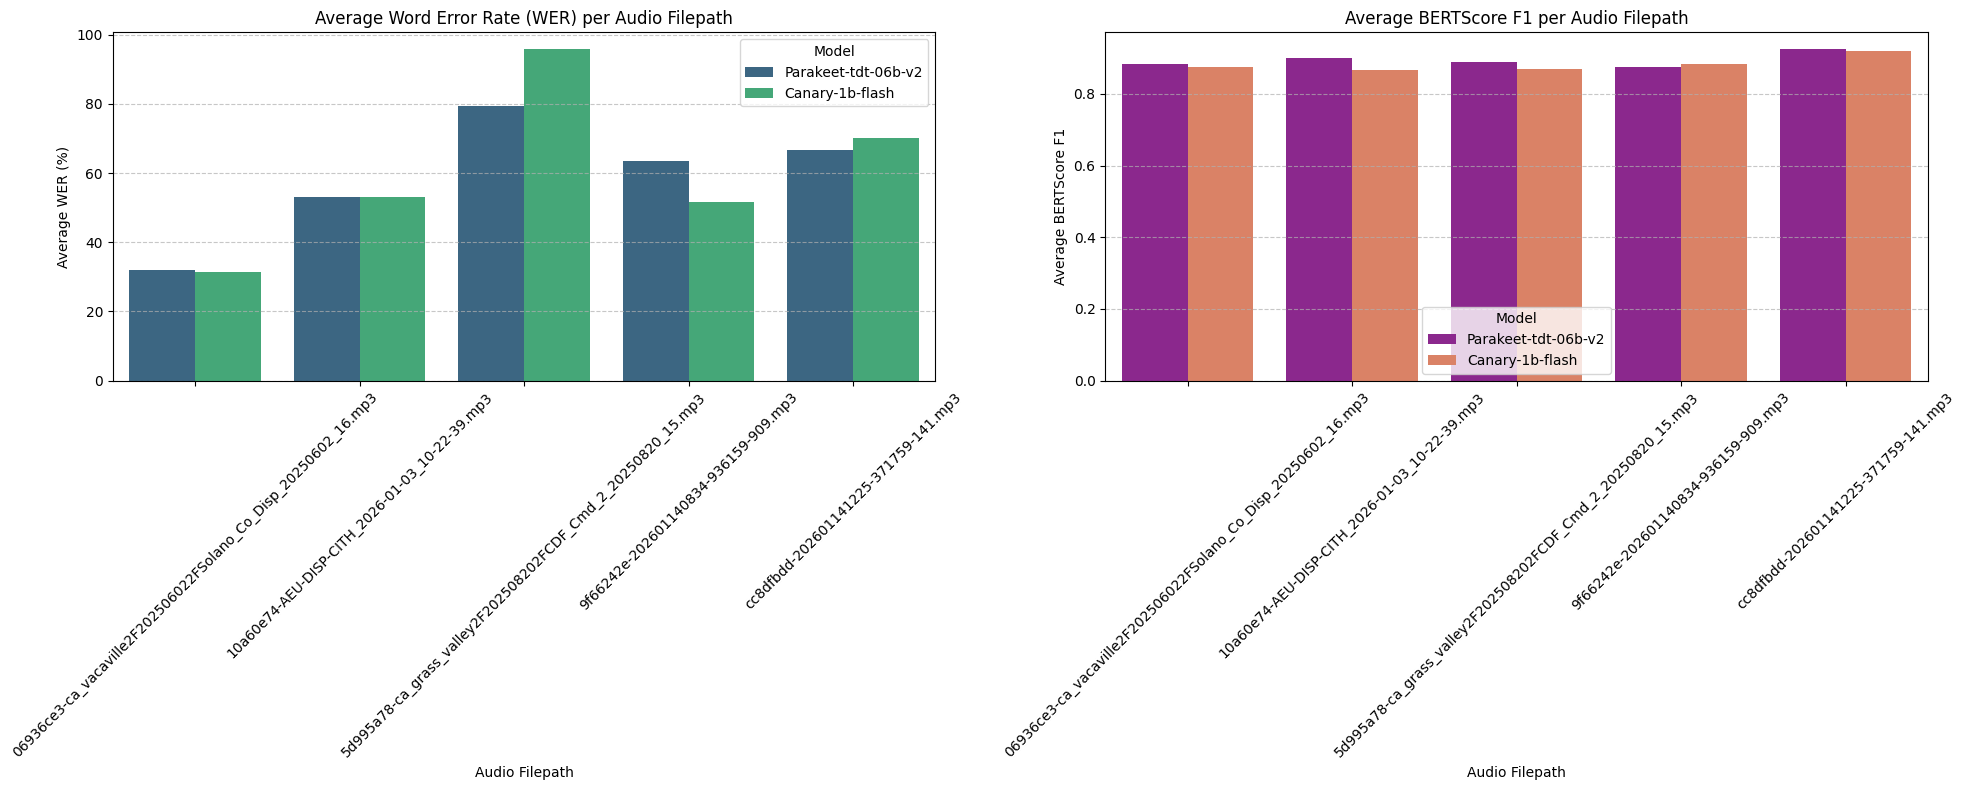

In [ ]:
#@title Visualize WER x BertScore per audio file
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Create a copy to avoid modifying the original DataFrame unintentionally
plot_df = avg_metrics_per_audio.copy()

# Extract short audio_filepath names for better plotting
plot_df['short_audio_filepath'] = plot_df['audio_filepath'].apply(lambda x: os.path.basename(x))

# Prepare data for Average WER plot
wer_plot_data = plot_df[['short_audio_filepath', 'mean_wer_parakeet', 'mean_wer_canary']]
wer_plot_data_melted = wer_plot_data.melt(
    id_vars='short_audio_filepath',
    var_name='Model',
    value_name='Average WER'
)
wer_plot_data_melted['Model'] = wer_plot_data_melted['Model'].replace({
    'mean_wer_parakeet': 'Parakeet-tdt-06b-v2',
    'mean_wer_canary': 'Canary-1b-flash'
})

# Prepare data for Average BERTScore F1 plot
bertscore_plot_data = plot_df[['short_audio_filepath', 'mean_bertscore_f1_parakeet', 'mean_bertscore_f1_canary']]
bertscore_plot_data_melted = bertscore_plot_data.melt(
    id_vars='short_audio_filepath',
    var_name='Model',
    value_name='Average BERTScore F1'
)
bertscore_plot_data_melted['Model'] = bertscore_plot_data_melted['Model'].replace({
    'mean_bertscore_f1_parakeet': 'Parakeet-tdt-06b-v2',
    'mean_bertscore_f1_canary': 'Canary-1b-flash'
})

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=False) # sharey=False because WER and BERTScore F1 scales are different

# Plot Average WER
sns.barplot(x='short_audio_filepath', y='Average WER', hue='Model', data=wer_plot_data_melted, ax=axes[0], palette='viridis')
axes[0].set_title('Average Word Error Rate (WER) per Audio Filepath')
axes[0].set_ylabel('Average WER (%)')
axes[0].set_xlabel('Audio Filepath')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot Average BERTScore F1
sns.barplot(x='short_audio_filepath', y='Average BERTScore F1', hue='Model', data=bertscore_plot_data_melted, ax=axes[1], palette='plasma')
axes[1].set_title('Average BERTScore F1 per Audio Filepath')
axes[1].set_ylabel('Average BERTScore F1')
axes[1].set_xlabel('Audio Filepath')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()